# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator


In [2]:
CLOCK_SHELVING_PULSE_TIME = 380e-6
SHELVING_PULSE_CLEAROUT_DURATION = 2200e-6
LMT_SELECTIVE_PI_TIME = 95e-6
LMT_PULSE_CLEAROUT_DURATION = 50e-6



def insert_clearouts_preserving_pulse_timing(sequence, placements):
    sequence = list(sequence)
    for mode, pulse_index, clearout_duration, label in reversed(placements):
        if mode == "after":
            freefall_index = pulse_index + 1
            if freefall_index >= len(sequence) or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} after pulse index {pulse_index}: expected a following Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: following Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = [seq.Clearout(duration=clearout_duration, label=label)]
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            sequence[freefall_index : freefall_index + 1] = replacement
        elif mode == "before":
            freefall_index = pulse_index - 1
            if freefall_index < 0 or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} before pulse index {pulse_index}: expected a preceding Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: preceding Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = []
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            replacement.append(seq.Clearout(duration=clearout_duration, label=label))
            sequence[freefall_index : freefall_index + 1] = replacement
        else:
            raise ValueError(f"Unsupported clearout placement mode: {mode!r}")

    return sequence


def add_true_lmt_clearouts(sequence, duration_tolerance=1e-6):
    if any(isinstance(event, seq.Clearout) for event in sequence):
        raise ValueError("Sequence already contains Clearout events")

    velocity_selection_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            CLOCK_SHELVING_PULSE_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(velocity_selection_indices) != 1:
        raise ValueError(
            f"Expected exactly one velocity-selection pulse in extracted sequence, found {len(velocity_selection_indices)}"
        )

    selective_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            LMT_SELECTIVE_PI_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(selective_indices) != 4:
        raise ValueError(
            "Expected exactly four selective 95 us pulses in extracted sequence"
        )

    placements = [
        (
            "after",
            velocity_selection_indices[0],
            SHELVING_PULSE_CLEAROUT_DURATION,
            "vs_clearout",
        ),
        (
            "after",
            selective_indices[0],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_upper",
        ),
        (
            "before",
            selective_indices[1],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_upper",
        ),
        (
            "after",
            selective_indices[2],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_lower",
        ),
        (
            "before",
            selective_indices[3],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_lower",
        ),
    ]
    return insert_clearouts_preserving_pulse_timing(sequence, placements)



In [3]:
pulse_sequence = [[[1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0], [4936, 2691191, 2771190, 2838189, 2918188, 2985187, 3065186, 3132185, 3212184, 3279183, 3359182, 3426181, 3506180, 3573179, 3653178, 3720177, 3800176, 4077207, 4122991, 4286111, 4392695, 4722709, 4809244, 4922367, 5030207, 5108734, 5221855, 5328439, 5508438, 5594973, 5908111, 6019623], [380000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 34000, 99999, 99999, 68000, 68000, 99999, 99999, 68000, 99999, 99999, 68000, 68000, 99999, 99999, 34000], [80000000, 79971814, 80020109, 79988550, 80003372, 80005286, 79986636, 80022022, 79969900, 80038758, 79953164, 80055494, 79936428, 80072230, 79919692, 80088966, 79902956, 80027353, 79983322, 79966812, 80004123, 79999490, 79974157, 79994546, 80013772, 79978362, 79998751, 80028585, 80026058, 80003989, 79989586, 80000149], [200000000, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800, 200000500, 200000500, 200005800, 200005800, 200000500, 200000500, 200005800], [99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300, 99485300], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

In [5]:
is_up

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0])

In [6]:
opll_hz

array([80000000, 79971814, 80020109, 79988550, 80003372, 80005286,
       79986636, 80022022, 79969900, 80038758, 79953164, 80055494,
       79936428, 80072230, 79919692, 80088966, 79902956, 80027353,
       79983322, 79966812, 80004123, 79999490, 79974157, 79994546,
       80013772, 79978362, 79998751, 80028585, 80026058, 80003989,
       79989586, 80000149])

In [7]:
switch_hz

array([200000000, 200005800, 200001500, 200005800, 200001500, 200005800,
       200001500, 200005800, 200001500, 200005800, 200001500, 200005800,
       200001500, 200005800, 200001500, 200005800, 200001500, 200005800,
       200000500, 200000500, 200005800, 200005800, 200000500, 200000500,
       200005800, 200000500, 200000500, 200005800, 200005800, 200000500,
       200000500, 200005800])

In [8]:
delivery_hz

array([99485300, 99485300, 99485300, 99485300, 99485300, 99485300,
       99485300, 99485300, 99485300, 99485300, 99485300, 99485300,
       99485300, 99485300, 99485300, 99485300, 99485300, 99485300,
       99485300, 99485300, 99485300, 99485300, 99485300, 99485300,
       99485300, 99485300, 99485300, 99485300, 99485300, 99485300,
       99485300, 99485300])

In [9]:
delivery_setpoint

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [11]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
PROBE_SHIFT_ALPHA, INITIAL_VELOCITY_Z = (
    seq.calibrate_probe_shift_and_velocity_from_dump(
        is_up=is_up,
        start_times_mu=start_times_mu,
        durations_mu=durations_mu,
        opll_hz=opll_hz,
        switch_hz=switch_hz,
        delivery_hz=delivery_hz,
        delivery_setpoint=delivery_setpoint,
    )
)
print(f"auto-calibrated probe-shift alpha = {PROBE_SHIFT_ALPHA:.4e} /Hz")
print(f"auto-calibrated initial velocity  = {INITIAL_VELOCITY_Z:.4e} m/s")

In [12]:
sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)

# Skip the first freefall
sequence = sequence[1:]

In [13]:
# sequence = add_true_lmt_clearouts(sequence)

In [14]:
# sequence = sequence[:15]
sequence

[Pulse(k=1, detuning_hz=np.float64(4738.456932067871), phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(0.002306255), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(15393.10713917017), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(1.199899999999995e-05), label='freefall'),
 Pulse(k=1, detuning_hz=np.float64(-12517.420989274979), phi=0.0, label='LMT', rabi_frequency=np.float64(9091.074383170602), duration=np.float64(5.4999000000000007e-05), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(1.1999999999999858e-05), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(34194.376389443874), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=n

In [15]:
sim.RECOIL_FREQUENCY_HZ * 2

9414.057215942552

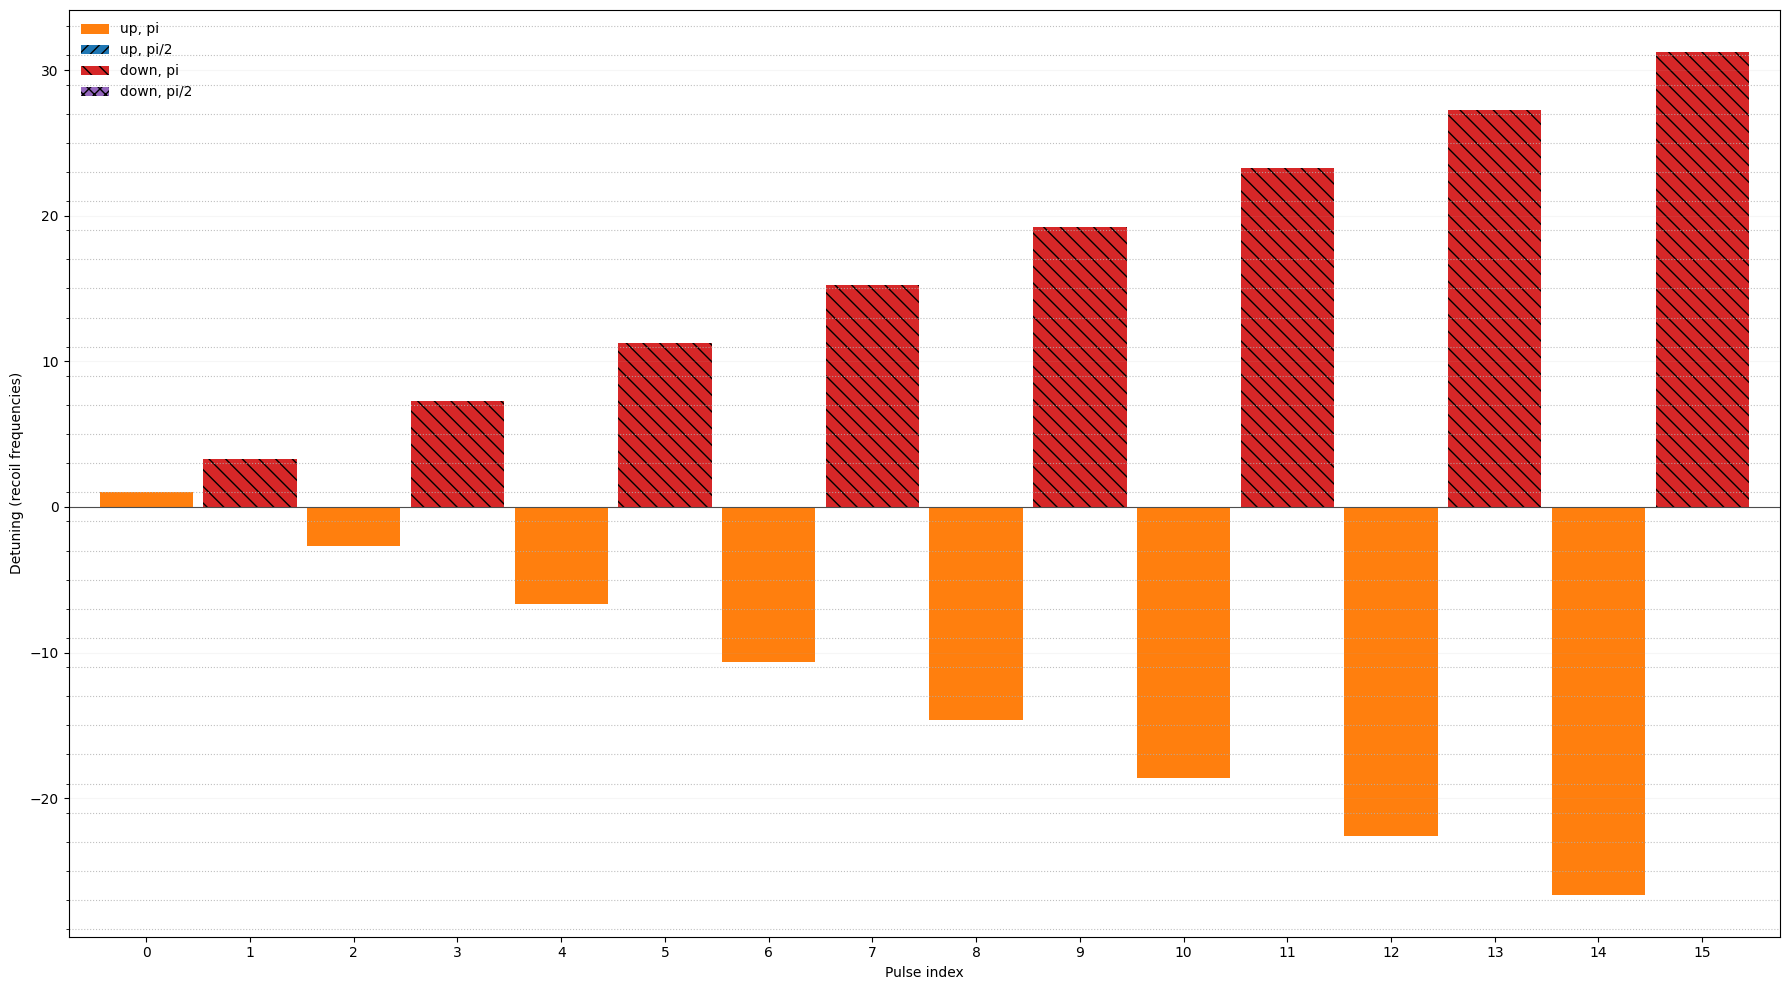

In [16]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)
# plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:32]

pulse_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)


y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)


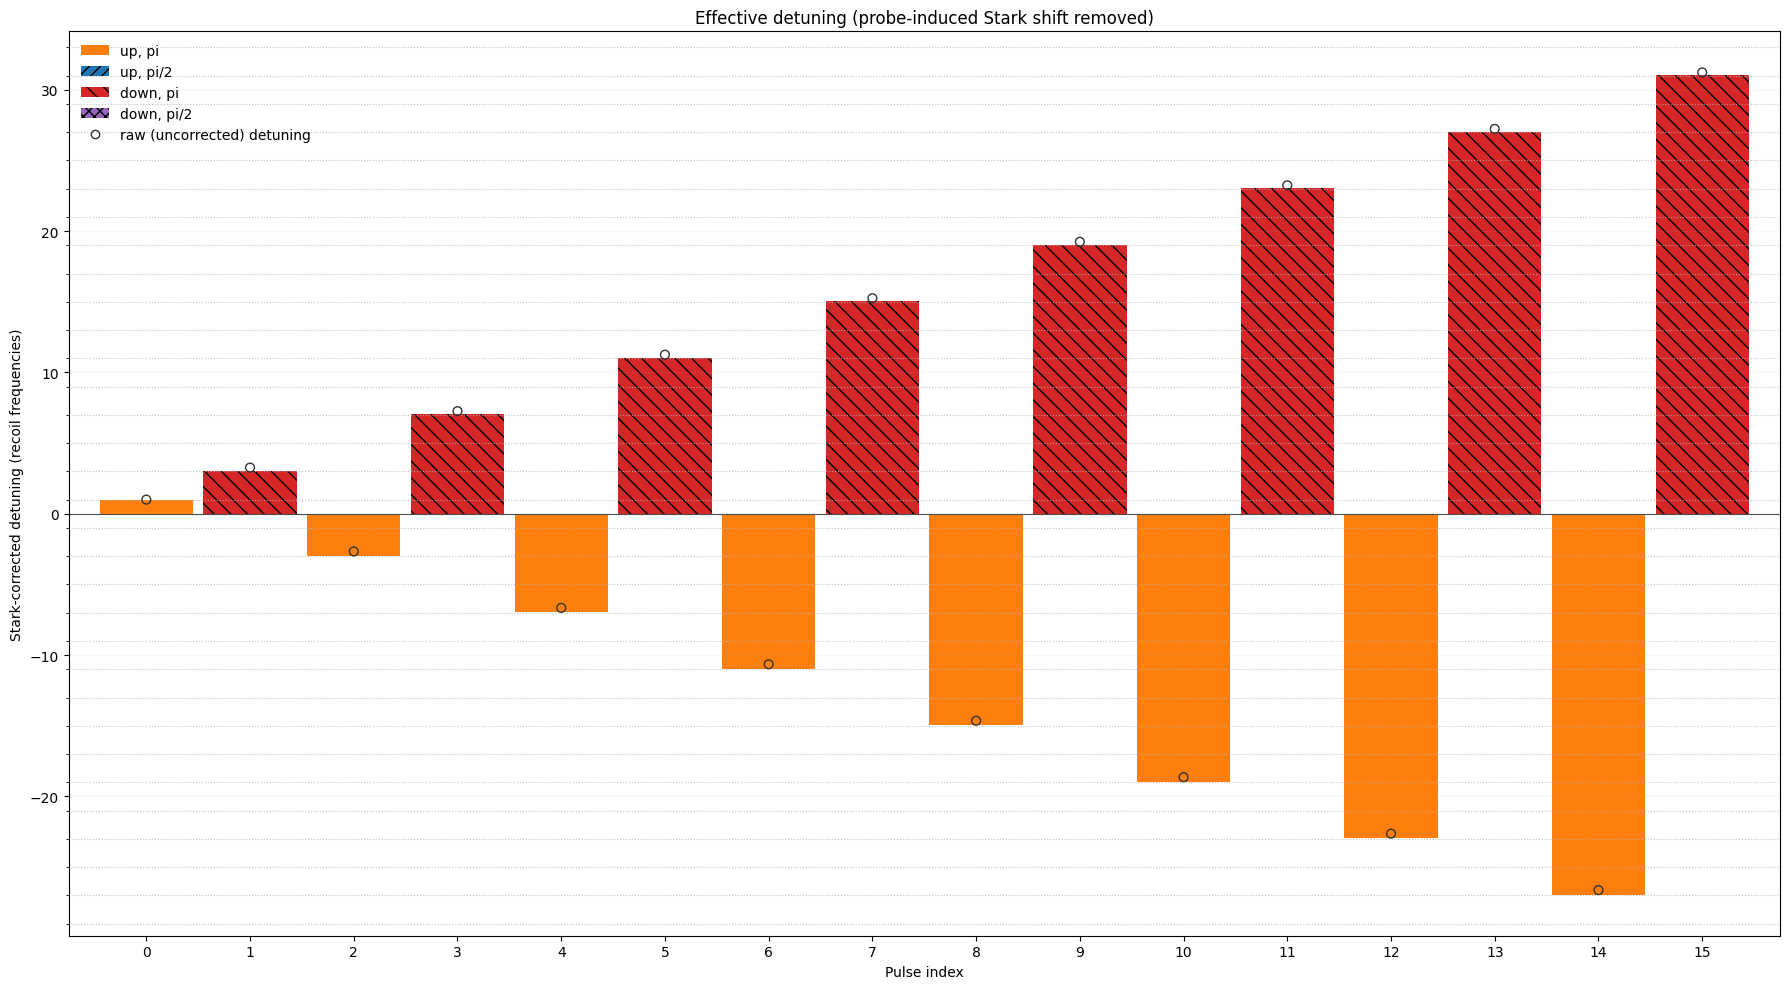

In [17]:
# Same bar plot, but with each pulse's detuning corrected for its
# probe-induced (AC-Stark) shift. The effective detuning the atom actually
# sees is detuning_hz - probe_shift_coefficient * rabi_frequency**2, so
# removing the Stark term should collapse the bars onto the clean recoil
# ladder (1, -3, 5, -7, ... in recoil units).

plot_sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)

# Truncate
plot_sequence = plot_sequence[:32]

raw_detunings_recoil = []
corrected_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True, True): ("tab:orange", ""),  # up,   pi
    (True, False): ("tab:blue", "///"),  # up,   pi/2
    (False, True): ("tab:red", "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),  # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(corrected_detunings_recoil)
    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2
    raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    corrected_detunings_recoil.append(
        (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
    )
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(corrected_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, corrected_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

# Show where the uncorrected (raw) detuning sat, for comparison.
ax.scatter(
    pulse_indices,
    raw_detunings_recoil,
    facecolor="none",
    edgecolor="0.2",
    marker="o",
    s=40,
    zorder=4,
)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            corrected_detunings_recoil[left_index],
            corrected_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Stark-corrected detuning (recoil frequencies)")
ax.set_title("Effective detuning (probe-induced Stark shift removed)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="", label="up, pi"),
    Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
    Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor="0.2",
        label="raw (uncorrected) detuning",
    ),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence_stark_corrected.png", dpi=300)

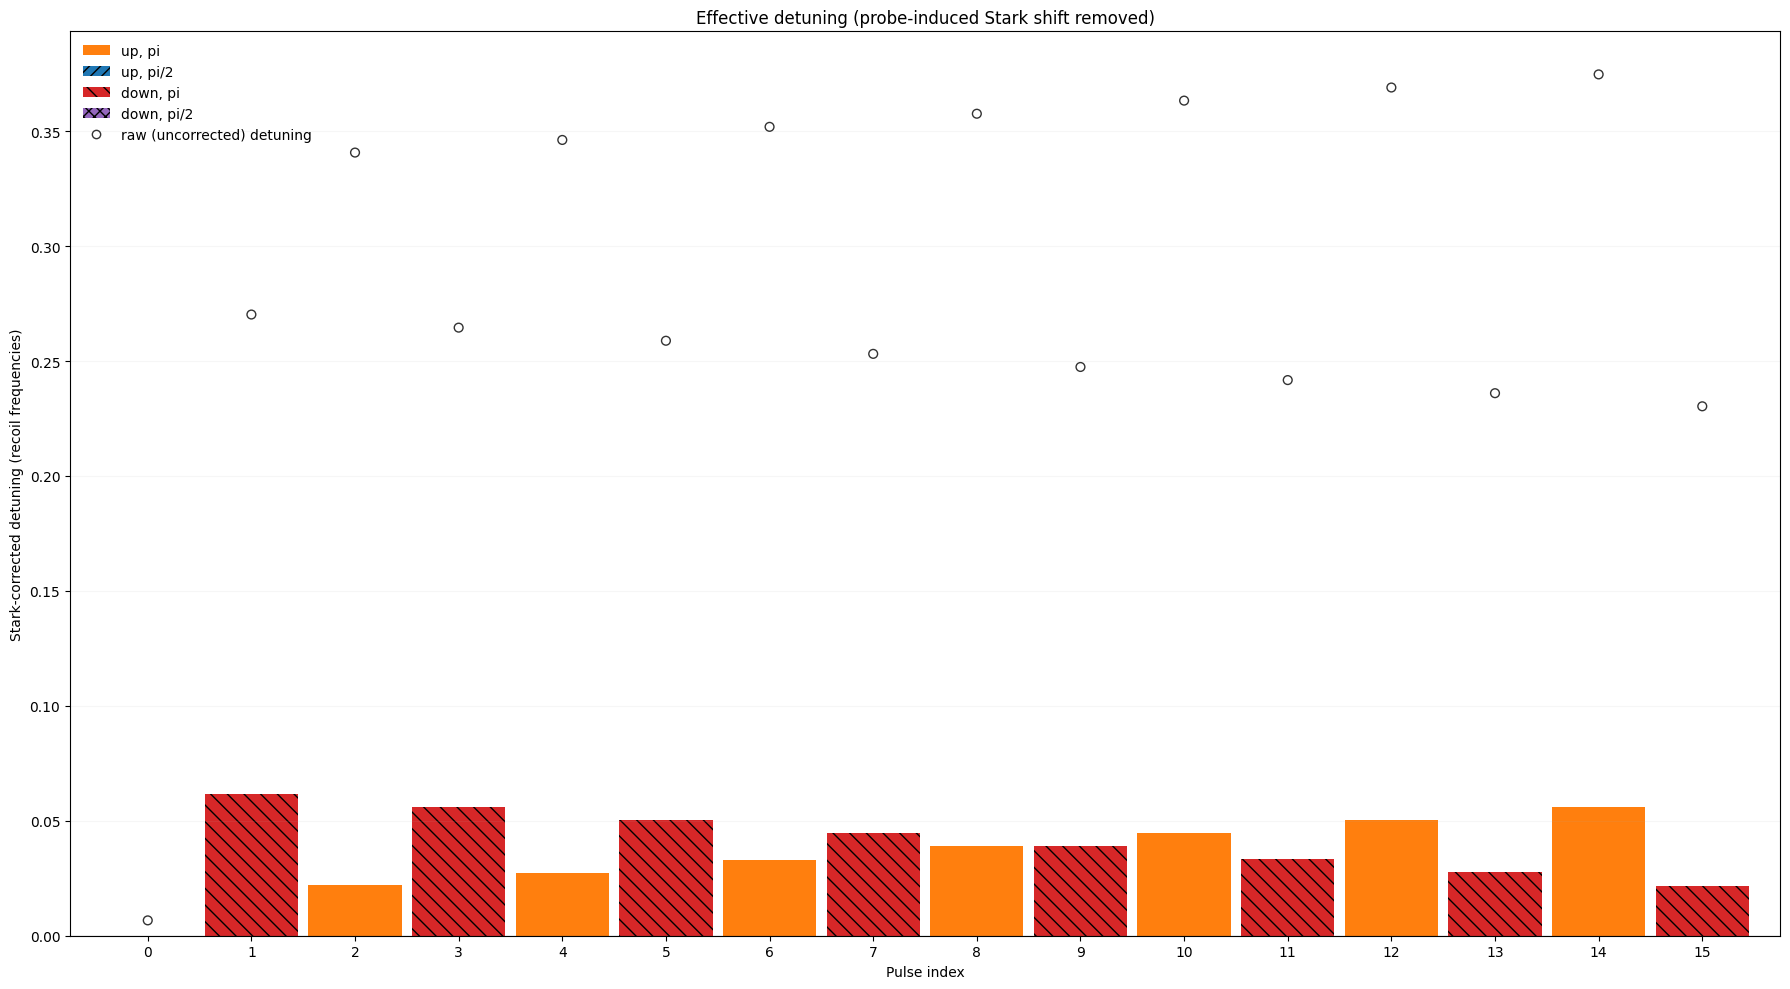

In [18]:
# Same bar plot, but with each pulse's detuning corrected for its
# probe-induced (AC-Stark) shift. The effective detuning the atom actually
# sees is detuning_hz - probe_shift_coefficient * rabi_frequency**2, so
# removing the Stark term should collapse the bars onto the clean recoil
# ladder (1, -3, 5, -7, ... in recoil units).

plot_sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)

# Truncate
plot_sequence = plot_sequence[:32]

raw_detunings_recoil = []
corrected_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(corrected_detunings_recoil)
    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2

    raw_detuning = event.detuning_hz / sim.RECOIL_FREQUENCY_HZ
    corrected_detuning = (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
    closest_integer = int(round(corrected_detuning))

    raw_detunings_recoil.append(raw_detuning - closest_integer)
    corrected_detunings_recoil.append(
        corrected_detuning - closest_integer
    )
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(corrected_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, corrected_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

# Show where the uncorrected (raw) detuning sat, for comparison.
ax.scatter(
    pulse_indices,
    raw_detunings_recoil,
    facecolor="none",
    edgecolor="0.2",
    marker="o",
    s=40,
    zorder=4,
)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            corrected_detunings_recoil[left_index],
            corrected_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Stark-corrected detuning (recoil frequencies)")
ax.set_title("Effective detuning (probe-induced Stark shift removed)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="0.2", label="raw (uncorrected) detuning"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence_stark_corrected.png", dpi=300)


In [19]:
(pulse_detunings_recoil[1] - pulse_detunings_recoil[0])

np.float64(2.2635618124476284)

The difference between these two should be 4 * the recoil frequency, neglecting the probe induced stark shift. The discepancy therefore gives us a check on the PSS:

In [20]:
detuning_01 = (plot_sequence[3].detuning_hz - plot_sequence[1].detuning_hz)
residual_detuning = detuning_01 - 4*sim.RECOIL_FREQUENCY_HZ
duration_0 = plot_sequence[3].duration
duration_1 = plot_sequence[1].duration

rabi_freq_0 = 1 / (4*duration_0)  # this is a pi/2
rabi_freq_1 = 1 / (2*duration_1)  # this is a pi

alpha = residual_detuning / (rabi_freq_1 **2 - rabi_freq_0 **2)
alpha

np.float64(0.0006935402000619059)

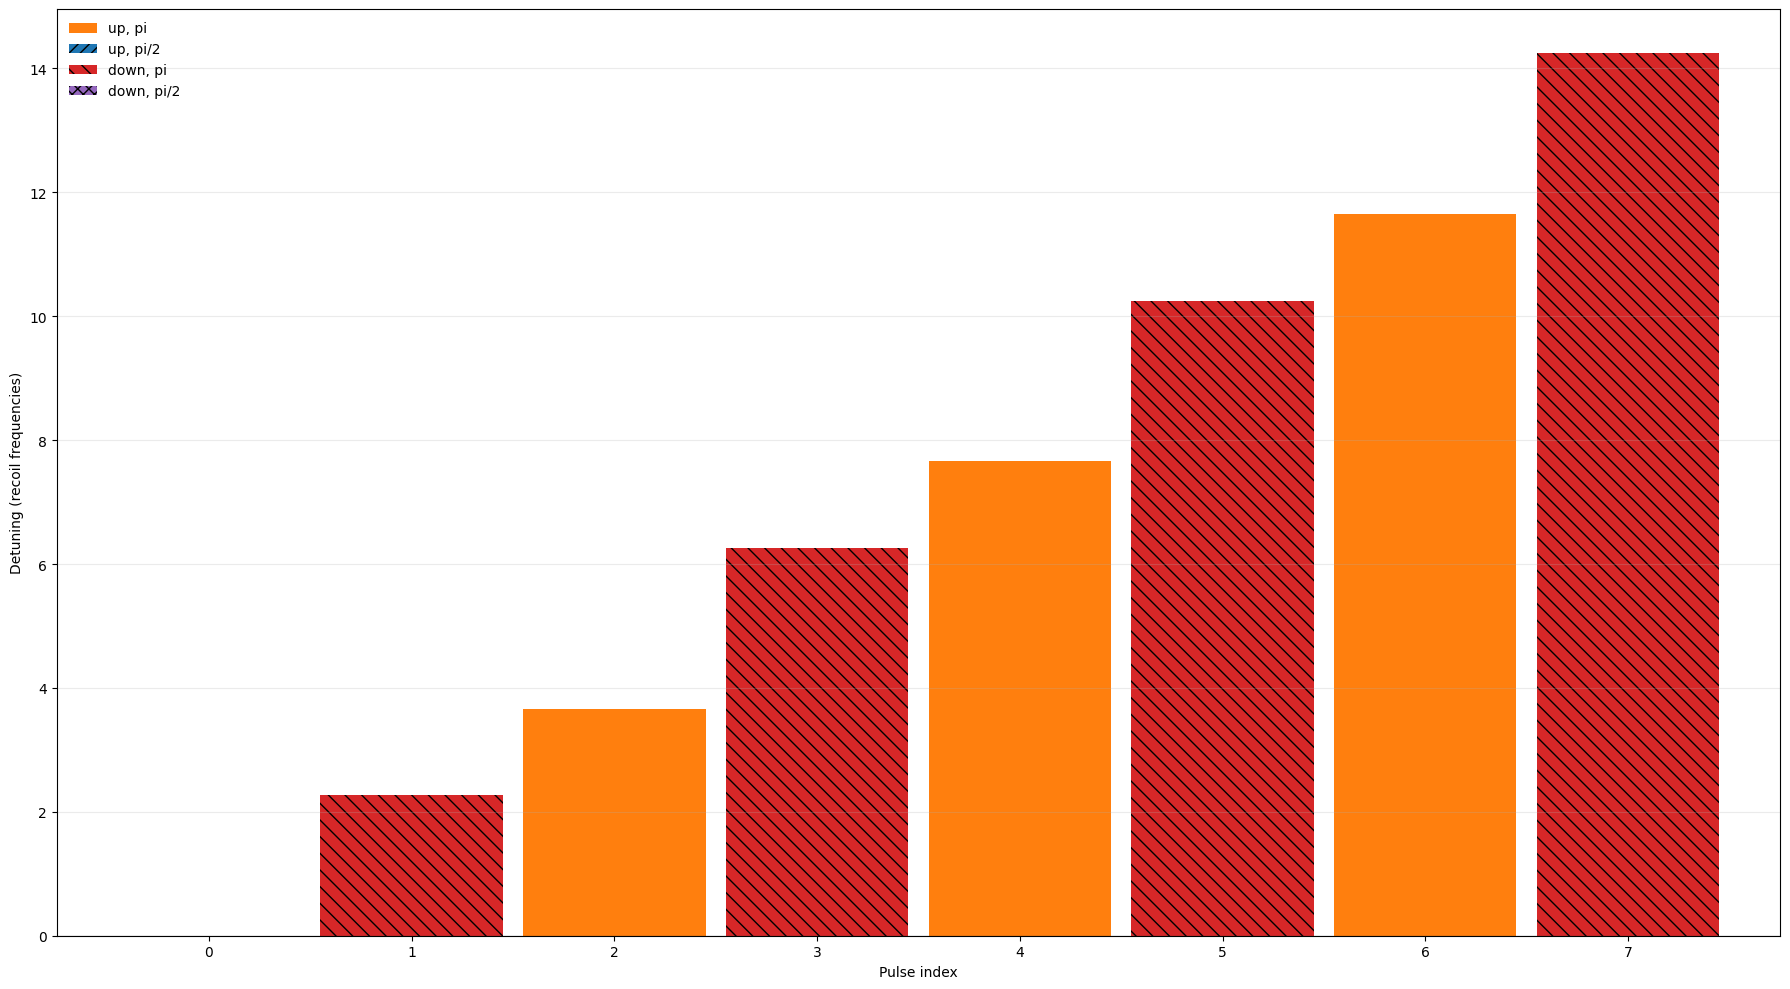

In [21]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)
# plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:16]

pulse_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

reference_detuning = None

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    if reference_detuning is None:
        reference_detuning = event.detuning_hz

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(np.abs(event.detuning_hz - reference_detuning) / sim.RECOIL_FREQUENCY_HZ)
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)


([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(0.00038), np.float64(0.0026862550000000002), np.float64(0.002754255), np.float64(0.002766254), np.float64(0.002821253), np.float64(0.002833253), np.float64(0.002901253), np.float64(0.0029132520000000003), np.float64(0.0029682510000000003), np.float64(0.002980251), np.float64(0.003048251), np.float64(0.00306025), np.float64(0.003115249), np.float64(0.003127249), np.float64(0.003195249), np.float64(0.003207248), np.float64(0.0032622470000000002), np.float64(0.003274247), np.float64(0.003342247), np.float64(0.003354246), np.float64(0.003409245), np.float64(0.0034212450000000003), np.float64(0.003489245), np.float64(0.003501244), np.float64(0.003556243), np.float64(0.003568243), np.float64(0.003636243), np.float64(0.0036482420000000003), np.float64(0.0037032410000000003), np.float64(0.003715241), np.float64(0.003783241), np.float64(0.00379524), np.float64(0.003850239), np.float64(0.004072271000000001), np.float64(0.004106

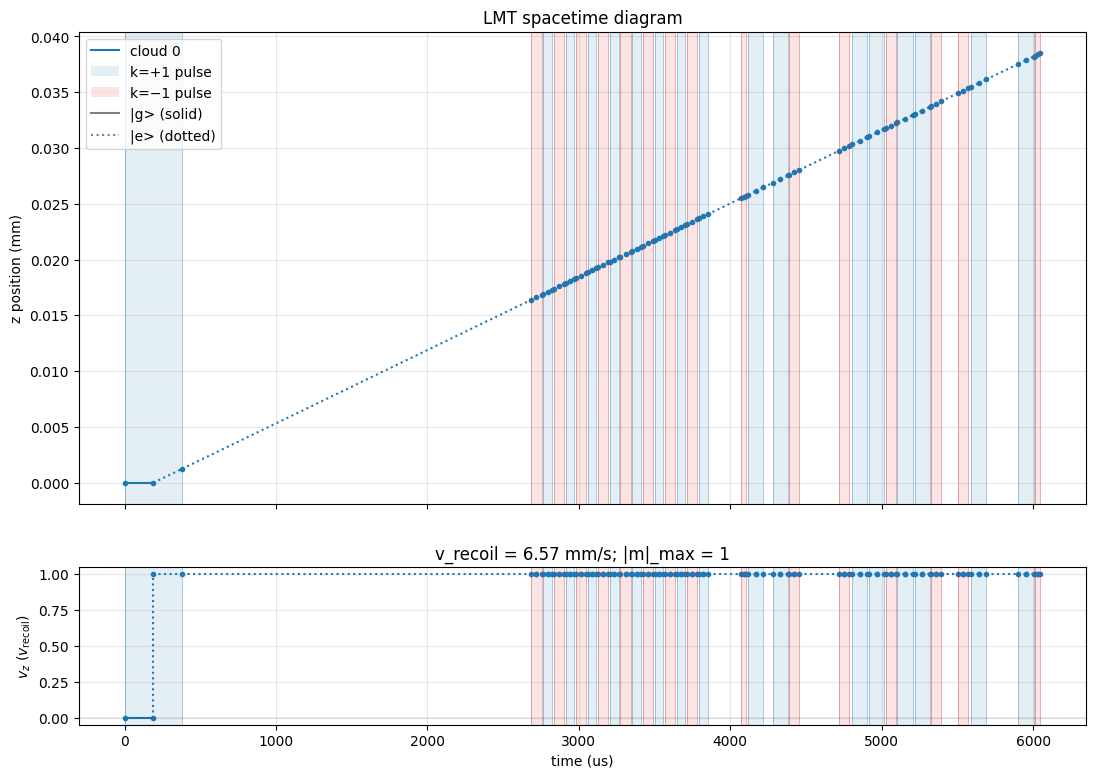

In [22]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)


In [23]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils
sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=INITIAL_VELOCITY_Z,
    probe_induced_alpha_up=PROBE_SHIFT_ALPHA,
    probe_induced_alpha_down=PROBE_SHIFT_ALPHA,
)

new_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        new_sequence.append(event)
        continue

    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2

    closest_integer = int(round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ))
    corrected_detuning = closest_integer * sim.RECOIL_FREQUENCY_HZ

    new_pulse = seq.Pulse(
        k=event.k,
        duration=event.duration,
        detuning_hz=corrected_detuning,
        rabi_frequency=event.rabi_frequency,
        phi=event.phi,
        label=event.label,
        probe_shift_coefficient=event.probe_shift_coefficient,
    )
    new_sequence.append(new_pulse)
    
# seq.compute_spacetime_trajectory(new_sequence, plot=True, max_branches=20)

new_sequence


[Freefall(duration=np.float64(4.936000000000001e-06), label='freefall'),
 Pulse(k=1, detuning_hz=4707.028607971276, phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(0.002306255), label='freefall'),
 Pulse(k=-1, detuning_hz=14121.085823913829, phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(1.199899999999995e-05), label='freefall'),
 Pulse(k=1, detuning_hz=-14121.085823913829, phi=0.0, label='LMT', rabi_frequency=np.float64(9091.074383170602), duration=np.float64(5.4999000000000007e-05), beam_waist=1000000.0, probe_shift_coefficient=1.8153e-05),
 Freefall(duration=np.float64(1.1999999999999858e-05), label='freefall'),
 Pulse(k=-1, detuning_hz=32949.20025579893, phi=0.0, label='LMT', rabi_frequency=np.float64(7352.

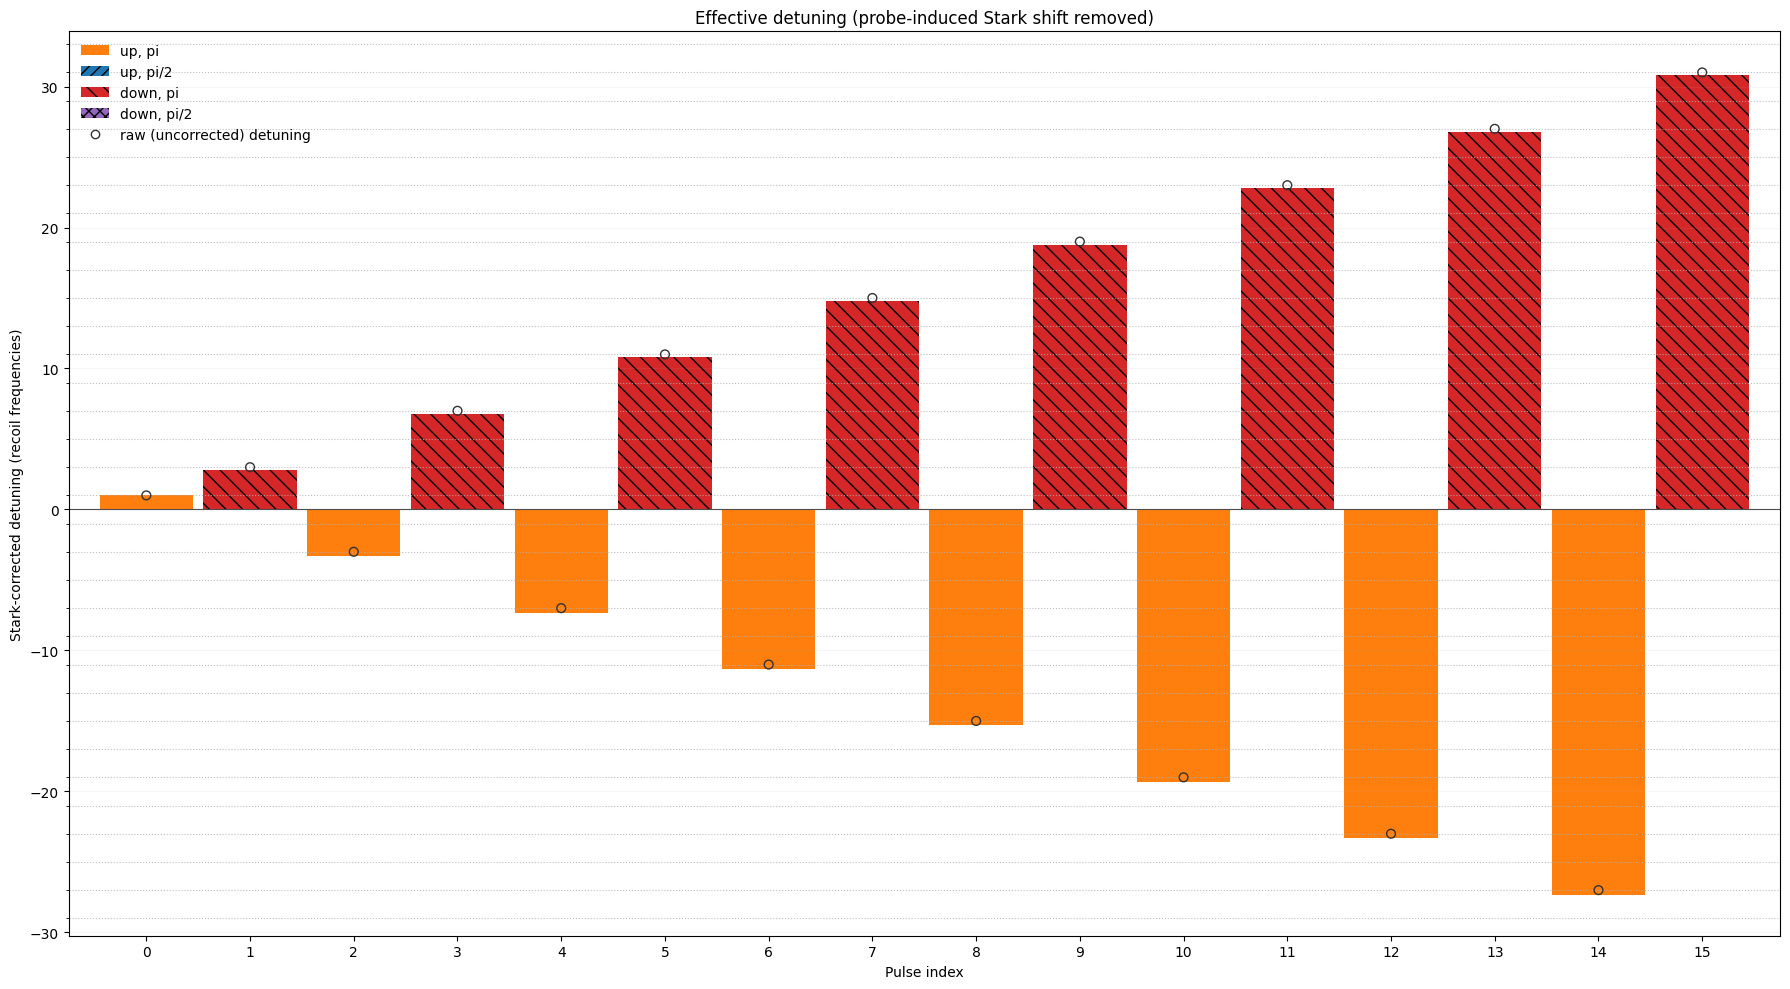

In [24]:
# Same bar plot, but with each pulse's detuning corrected for its
# probe-induced (AC-Stark) shift. The effective detuning the atom actually
# sees is detuning_hz - probe_shift_coefficient * rabi_frequency**2, so
# removing the Stark term should collapse the bars onto the clean recoil
# ladder (1, -3, 5, -7, ... in recoil units).

plot_sequence = new_sequence

# Truncate
plot_sequence = plot_sequence[:32]

raw_detunings_recoil = []
corrected_detunings_recoil = []
pulse_colours = []
pulse_hatches = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

PULSE_STYLES = {
    #              colour          hatch
    (True,  True):  ("tab:orange", ""),      # up,   pi
    (True,  False): ("tab:blue",   "///"),   # up,   pi/2
    (False, True):  ("tab:red",    "\\\\"),  # down, pi
    (False, False): ("tab:purple", "xxx"),   # down, pi/2
}

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(corrected_detunings_recoil)
    probe_shift_hz = event.probe_shift_coefficient * event.rabi_frequency**2
    raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    corrected_detunings_recoil.append(
        (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
    )
    colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
    pulse_colours.append(colour)
    pulse_hatches.append(hatch)

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(corrected_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.bar(pulse_indices, corrected_detunings_recoil, color=pulse_colours, width=0.9)
for bar, hatch in zip(bars, pulse_hatches):
    bar.set_hatch(hatch)

# Show where the uncorrected (raw) detuning sat, for comparison.
ax.scatter(
    pulse_indices,
    raw_detunings_recoil,
    facecolor="none",
    edgecolor="0.2",
    marker="o",
    s=40,
    zorder=4,
)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            corrected_detunings_recoil[left_index],
            corrected_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Stark-corrected detuning (recoil frequencies)")
ax.set_title("Effective detuning (probe-induced Stark shift removed)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

y_min, y_max = ax.get_ylim()
odd_tick_start = int(np.floor(y_min))
if odd_tick_start % 2 == 0:
    odd_tick_start += 1
odd_tick_stop = int(np.ceil(y_max))
odd_minor_ticks = np.arange(odd_tick_start, odd_tick_stop + 1, 2)
ax.yaxis.set_minor_locator(FixedLocator(odd_minor_ticks))
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.8)
ax.grid(axis="y", which="major", linestyle="-", alpha=0.1)

legend_handles = [
    Patch(facecolor="tab:orange", hatch="",     label="up, pi"),
    Patch(facecolor="tab:blue",   hatch="///",  label="up, pi/2"),
    Patch(facecolor="tab:red",    hatch="\\\\", label="down, pi"),
    Patch(facecolor="tab:purple", hatch="xxx",  label="down, pi/2"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="none",
           markeredgecolor="0.2", label="raw (uncorrected) detuning"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence_stark_corrected.png", dpi=300)


In [25]:
corrected_detunings_recoil

[np.float64(0.9933231074809065),
 np.float64(2.7914915052428384),
 np.float64(-3.3187366414773365),
 np.float64(6.791491505242838),
 np.float64(-7.3187366414773365),
 np.float64(10.791491505242838),
 np.float64(-11.318736641477336),
 np.float64(14.791491505242837),
 np.float64(-15.318736641477335),
 np.float64(18.79149150524284),
 np.float64(-19.318736641477336),
 np.float64(22.79149150524284),
 np.float64(-23.318736641477336),
 np.float64(26.79149150524284),
 np.float64(-27.318736641477336),
 np.float64(30.791491505242842)]

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.002691191), np.float64(0.002759191), np.float64(0.0027711899999999998), np.float64(0.002826189), np.float64(0.0028381889999999996), np.float64(0.0029061889999999996), np.float64(0.002918188), np.float64(0.002973187), np.float64(0.002985187), np.float64(0.0030531869999999997), np.float64(0.0030651859999999997), np.float64(0.0031201849999999997), np.float64(0.0031321849999999996), np.float64(0.0032001849999999995), np.float64(0.003212184), np.float64(0.003267183), np.float64(0.0032791829999999998), np.float64(0.0033471829999999997), np.float64(0.0033591819999999996), np.float64(0.0034141809999999996), np.float64(0.003426181), np.float64(0.003494181), np.float64(0.00350618), np.float64(0.003561179), np.float64(0.0035731789999999997), np.float64(0.0036411789999999996), np.float64(0.003653178), np.float64(0.003708177), np.float64(0.003720177), np.float64(0.00378

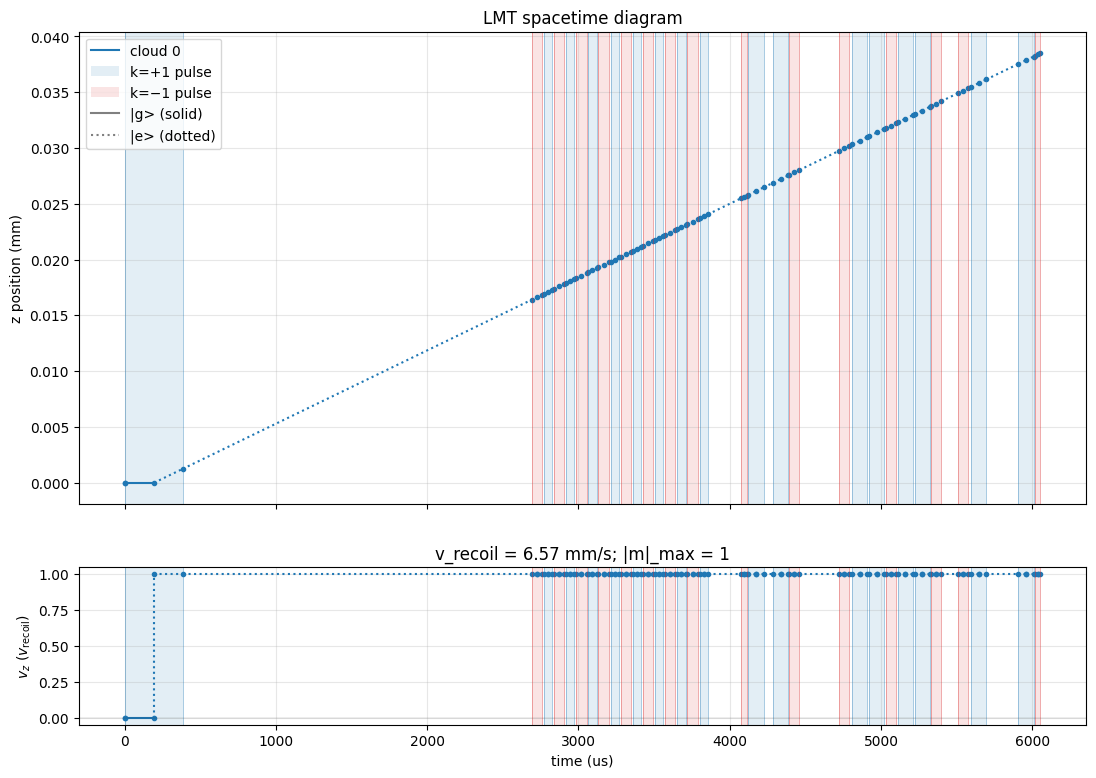

In [26]:
seq.compute_spacetime_trajectory(new_sequence, plot=True, max_branches=20)
